# Absorbing chains: a loan book that answers its own questions

Notebook 01 studied chains that circulate forever and asked where they
spend their time. This notebook is about the other family: chains
containing a state you can enter but never leave. Such a state is called
**absorbing**, and once you start looking, real systems are full of
them. A repaid loan stays repaid. A churned subscriber stays churned. A
finished game stays finished. In every case the process wanders among
"live" states for a while and then falls into an exit it never comes
out of.

Our running example is a small loan portfolio. Each loan sits in one of
four states, reviewed once a year:

- **GL**, a good loan, paying on schedule
- **RL**, a risky loan, showing signs of stress
- **PU**, paid up in full. Absorbing: the story is over, happily
- **BL**, a bad loan, written off. Absorbing: over, unhappily

Where would the transition matrix come from in real life? From
migration counts. Take every loan that was GL at the start of a year,
record where each stood a year later, and turn the counts into
fractions; repeat per state. Banks maintain exactly such tables under
names like migration matrices or roll rates. The numbers below are
illustrative rather than taken from a real book, but their shape (good
loans mostly stay good, risky loans default at a frightening clip) is
the shape you would see in practice.

The questions worth money here are all long-run ones. What fraction of
today's book eventually defaults? How many years will the loans stay on
the balance sheet? What will it cost to service them until they resolve?
Absorbing chains answer all three exactly, and this notebook builds that
machinery from scratch.

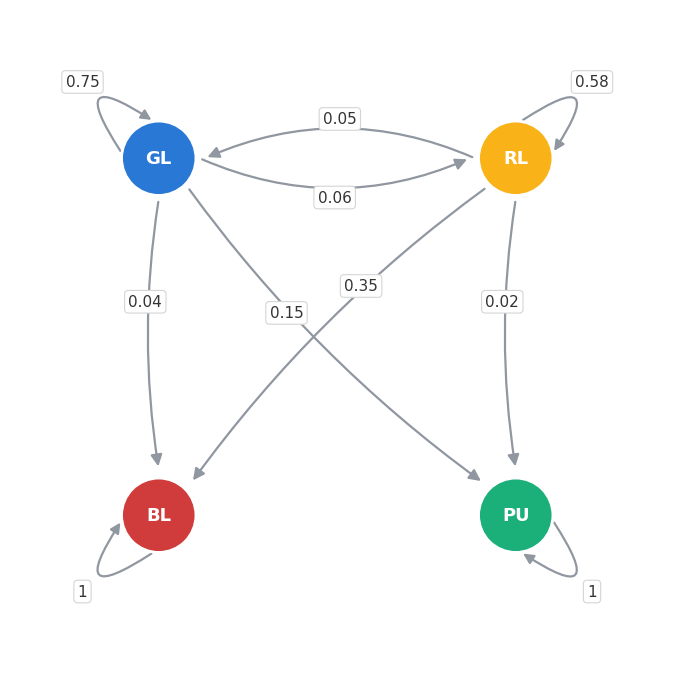

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

from markov import AbsorbingChain, MarkovChain

np.set_printoptions(precision=4, suppress=True)
%matplotlib inline

BLUE, ORANGE, GREEN = '#2a78d6', '#eb6834', '#1baf7a'
AMBER, RED, INK = '#fab219', '#d03b3b', '#333333'

plt.rcParams.update({
    'figure.dpi': 100,
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.edgecolor': '#666666', 'axes.linewidth': 0.9,
    'axes.grid': True, 'grid.alpha': 0.25,
    'axes.titlesize': 13, 'axes.titleweight': 'semibold',
    'axes.titlelocation': 'left', 'axes.titlecolor': INK,
    'axes.labelsize': 11, 'axes.labelcolor': '#444444',
    'xtick.color': '#666666', 'ytick.color': '#666666',
    'legend.frameon': False, 'font.size': 11,
})

P = np.array([[0.75, 0.06, 0.15, 0.04],
              [0.05, 0.58, 0.02, 0.35],
              [0.00, 0.00, 1.00, 0.00],
              [0.00, 0.00, 0.00, 1.00]])
states = ['GL', 'RL', 'PU', 'BL']

STATE_COLORS = {'GL': BLUE, 'RL': AMBER, 'PU': GREEN, 'BL': RED}
MarkovChain(P, states, node_colors=STATE_COLORS).draw('../pic/loan_chain.png')

Read the picture the way a risk manager would. The two bottom states
each carry a self-loop of probability 1, the visual signature of an
absorbing state: all roads in, none out. Everything interesting happens
in the top row. A good loan usually stays good (0.75), pays off at a
healthy 0.15 a year, and only rarely deteriorates. The risky state is
where the danger lives: a risky loan cures back to good just 5% of the
time, almost never manages to pay off from there (0.02), and defaults
at a brutal 35% per year.

One glance at those two 1.0 self-loops also tells you the question from
notebook 01 has died. Asking for this chain's long-run share of time per
state gets a true but useless answer: eventually all probability sits in
PU and BL, and the live states get a share of zero. The interesting
questions are new ones. *Which* exit does each loan take, *when*, and
what happens along the way?

## First pass: push the whole portfolio forward

Before any clever machinery, brute force deserves a chance, and it
teaches the mechanics. Describe a portfolio as a row vector of
probability mass over the four states. A book that is 90% good loans and
10% risky is the vector $(0.9, 0.1, 0, 0)$. One year of migration is one
multiplication by $P$: the new vector is `mix @ P`, exactly the
"multiply along routes, add across routes" rule from notebook 01, applied
to a whole population at once.

We will track three books of very different quality: A is 90/10 good to
risky, B is an even 50/50, and C is a distressed 20/80.

In [2]:
def roll_forward(mix, n_years):
    """Year-by-year state mix of a portfolio under P."""
    state = np.array(mix, dtype=float)
    rows = [state.copy()]
    for _ in range(n_years):
        state = state @ P
        rows.append(state.copy())
    return pd.DataFrame(rows, columns=states).rename_axis('year')

port_a = [0.9, 0.1, 0.0, 0.0]
port_b = [0.5, 0.5, 0.0, 0.0]
port_c = [0.2, 0.8, 0.0, 0.0]

roll_forward(port_a, 10).round(4)

,GL,RL,PU,BL
year,,,,
0,0.9000,0.1000,0.0000,0.0000
1,0.6800,0.1120,0.1370,0.0710
2,0.5156,0.1058,0.2412,0.1374
3,0.3920,0.0923,0.3207,0.1950
4,0.2986,0.0770,0.3813,0.2430
5,0.2278,0.0626,0.4277,0.2819
6,0.1740,0.0500,0.4631,0.3129
7,0.1330,0.0394,0.4902,0.3374
8,0.1017,0.0308,0.5109,0.3565


Ten rows in and the drift is unmistakable: the GL column melts, PU and
BL grow and never shrink. A chart makes the whole flow visible at once.
Here is the distressed portfolio C over thirty years, with the live
states sandwiched between the two exits so you can watch the middle
drain away.

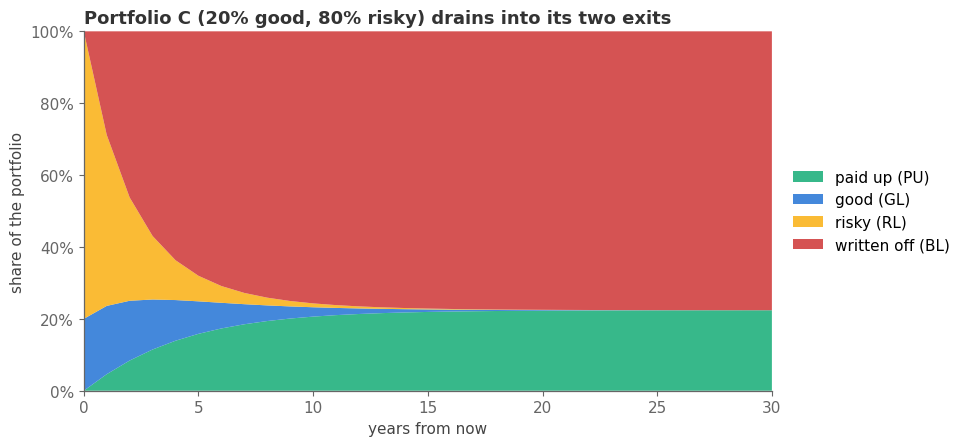

In [3]:
mass = roll_forward(port_c, 30)

fig, ax = plt.subplots(figsize=(9.8, 4.6))
ax.stackplot(mass.index,
             mass['PU'], mass['GL'], mass['RL'], mass['BL'],
             labels=['paid up (PU)', 'good (GL)', 'risky (RL)',
                     'written off (BL)'],
             colors=[GREEN, BLUE, AMBER, RED], alpha=0.88)
ax.set_xlim(0, 30)
ax.set_ylim(0, 1)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax.set_xlabel('years from now')
ax.set_ylabel('share of the portfolio')
ax.set_title('Portfolio C (20% good, 80% risky) drains into its two exits')
ax.legend(loc='center left', bbox_to_anchor=(1.01, 0.5))
ax.grid(False)
fig.tight_layout()

The amber band, risky loans, is nearly gone within a decade; almost all
of it falls off the red cliff rather than escaping to green. The blue
band of good loans dies more slowly. By year 30 the book is essentially
resolved.

Iteration got us this far and it is worth being precise about what it
cannot do, because the gaps are what the exact theory fills:

1. It only ever *approaches* the final split. To report "the eventual
   default rate", you must pick a cutoff year and hope the leftover is
   negligible.
2. It describes the population's calendar, not an individual loan's
   clock. "How long does a risky loan take to resolve, on average?" is
   invisible in these tables.
3. It offers no handle for accumulating anything along the way, such as
   servicing cost per year spent alive.

## Reorder the states and the matrix falls into blocks

The exact route starts with pure bookkeeping. List the transient (live)
states first and the absorbing ones last, and the transition matrix
organizes itself into four blocks:

$$P = \begin{pmatrix} Q & R \\ 0 & I \end{pmatrix}$$

- $Q$ is transient to transient: movement among the living. Here, the
  2x2 corner for GL and RL.
- $R$ is transient to absorbing: the exit ramps.
- The bottom blocks just restate "absorbing states stay put", zeros and
  an identity.

The names matter less than the separation: $Q$ carries everything about
*staying alive*, $R$ everything about *how you leave*.

In [4]:
chain = AbsorbingChain(P, states)

print("Q, movement among live states:")
display(pd.DataFrame(chain.Q, index=chain.transient_states,
                     columns=chain.transient_states))
print("R, exits from live states:")
display(pd.DataFrame(chain.R, index=chain.transient_states,
                     columns=chain.absorbing_states))

Q, movement among live states:


,GL,RL
GL,0.75,0.06
RL,0.05,0.58


R, exits from live states:


,PU,BL
GL,0.15,0.04
RL,0.02,0.35


## Counting visits with a geometric series

Now the central object. Pick a live state to start in and ask: how many
years, in expectation, will the loan spend in each live state before it
is absorbed?

Take it one year at a time. The probability of being in live state $j$
at year zero is given by $I$ (you are where you started). At year one it
is given by $Q$; at year two by $Q^2$, since surviving two years means
two transient-to-transient moves; and so on. Expected total visits is
the sum over all years:

$$N = I + Q + Q^2 + Q^3 + \cdots$$

You have met this series with plain numbers: for $|q| < 1$,
$1 + q + q^2 + \cdots = \frac{1}{1 - q}$. The matrix version has the
same closed form, and it converges for the same reason. Some probability
leaks out of the live states every year (loans keep resolving), so
$Q^k$ shrinks toward zero and the sum settles at

$$N = (I - Q)^{-1}$$

which is called the **fundamental matrix**. One matrix inversion
replaces the infinite sum. Watch the convergence happen: here is the
partial sum's estimate of "expected years still on the books" as we add
terms, one curve per starting state, with the exact answer from the
inversion drawn as the dashed ceiling.

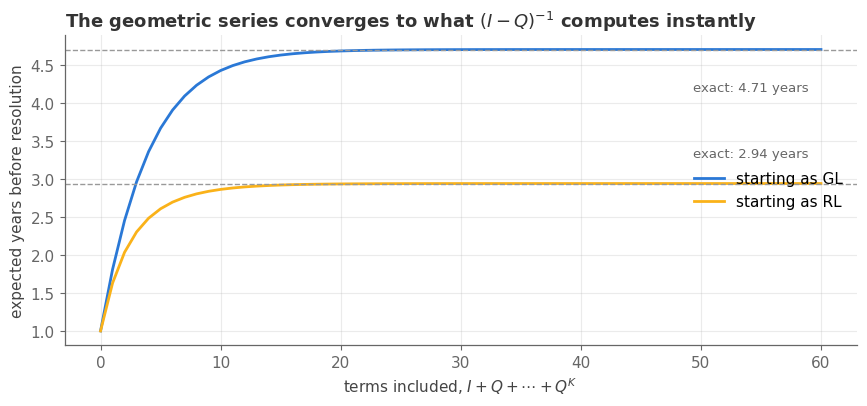

In [5]:
exact = chain.expected_steps()

partials, S, Qk = [], np.zeros((2, 2)), np.eye(2)
for K in range(61):
    S = S + Qk
    partials.append(S.sum(axis=1))
    Qk = Qk @ chain.Q
partials = np.array(partials)

fig, ax = plt.subplots(figsize=(8.8, 4.2))
ax.plot(partials[:, 0], lw=2, color=BLUE, label='starting as GL')
ax.plot(partials[:, 1], lw=2, color=AMBER, label='starting as RL')
for v in exact:
    ax.axhline(v, color='#999999', ls='--', lw=1)
ax.annotate(f'exact: {exact[0]:.2f} years', xy=(60, exact[0]),
            xytext=(59, exact[0] - 0.55), ha='right', fontsize=9.5,
            color='#666666')
ax.annotate(f'exact: {exact[1]:.2f} years', xy=(60, exact[1]),
            xytext=(59, exact[1] + 0.35), ha='right', fontsize=9.5,
            color='#666666')
ax.set_xlabel('terms included, $I + Q + \\cdots + Q^K$')
ax.set_ylabel('expected years before resolution')
ax.set_title('The geometric series converges to what $(I-Q)^{-1}$ computes instantly')
ax.legend(loc='center right')
fig.tight_layout()

Thirty or so terms in, the series is flat and sitting exactly on the
inversion's answer. From here on we use $N$ directly and read three
things straight off it:

- **$N[i, j]$ itself**: expected years spent in live state $j$, for a
  loan starting in state $i$.
- **Row sums of $N$**: expected years until the loan resolves, since a
  loan's lifetime is just the total of its live visits.
- **$B = N R$**: the probability of each ending. The logic: accumulate
  visits ($N$), and on each visit take the exit ramps with the
  probabilities in $R$. Row $i$, column $j$ of $B$ is the chance that a
  loan starting in $i$ is eventually absorbed in $j$, and its rows sum
  to 1 because every loan ends somewhere.

In [6]:
print("N, expected years in each live state:")
display(pd.DataFrame(chain.N, index=chain.transient_states,
                     columns=chain.transient_states).round(3))

print("expected years until resolution (row sums of N):")
for s, t in zip(chain.transient_states, chain.expected_steps()):
    print(f"  starting as {s}: {t:.2f} years")

print("\nB = N R, probability of each ending:")
display(pd.DataFrame(chain.absorption_probabilities(),
                     index=chain.transient_states,
                     columns=chain.absorbing_states).round(4))

N, expected years in each live state:


,GL,RL
GL,4.118,0.588
RL,0.490,2.451


expected years until resolution (row sums of N):
  starting as GL: 4.71 years
  starting as RL: 2.94 years

B = N R, probability of each ending:


,PU,BL
GL,0.6294,0.3706
RL,0.1225,0.8775


Read the RL row aloud, because this is the notebook's payoff. A loan
that is risky today will spend, on average, about half a year of its
remaining life as a good loan (it might cure) and two and a half years
as a risky one, resolving in just under three years, and it ends in a
write-off 88% of the time. No horizon was chosen. Nothing was
simulated. This is the exact destination that the
thirty-year iteration was crawling toward, plus the per-loan timing that
iteration could never see.

The portfolio versions are now one-liners: weight the rows of $B$ by the
starting mix. And as a cross-check on the whole edifice, rolling a
portfolio forward for two centuries should land on the same split that
$B$ predicts from pure algebra.

In [7]:
B = chain.absorption_probabilities()

for name, mix in [('A (90/10)', port_a), ('B (50/50)', port_b),
                  ('C (20/80)', port_c)]:
    ending = np.array(mix[:2]) @ B
    print(f"portfolio {name}: eventually {ending[0]:.1%} paid up, "
          f"{ending[1]:.1%} written off")

far = np.array(port_c) @ np.linalg.matrix_power(P, 200)
via_B = np.array(port_c[:2]) @ B
print(f"\ncross-check, portfolio C: iterate 200 years -> PU {far[2]:.4f}, "
      f"BL {far[3]:.4f}")
print(f"                          algebra (B)      -> PU {via_B[0]:.4f}, "
      f"BL {via_B[1]:.4f}")

portfolio A (90/10): eventually 57.9% paid up, 42.1% written off
portfolio B (50/50): eventually 37.6% paid up, 62.4% written off
portfolio C (20/80): eventually 22.4% paid up, 77.6% written off

cross-check, portfolio C: iterate 200 years -> PU 0.2239, BL 0.7761
                          algebra (B)      -> PU 0.2239, BL 0.7761


## Putting money on it

$N$ has one more gift. Suppose servicing a good loan costs about
\$120 a year in monitoring and paperwork, while a risky loan costs
\$900 a year once collections calls and restructuring reviews
begin. Since $N$ counts
expected years in each live state, expected lifetime servicing cost is
just $N \cdot c$ for the cost vector $c$: years in each state, priced.
This is the pattern behind loan-loss provisioning, customer lifetime
value, and (in notebook 04) the compute bill of an AI agent.

In [8]:
cost = chain.expected_cost([120, 900])
for s, v in zip(chain.transient_states, cost):
    print(f"expected lifetime servicing cost, starting as {s}: ${v:,.0f}")

blend = np.array(port_c[:2]) @ cost
print(f"\nportfolio C blend, per loan: ${blend:,.0f}")

expected lifetime servicing cost, starting as GL: $1,024
expected lifetime servicing cost, starting as RL: $2,265

portfolio C blend, per loan: $2,016


## Trust, but verify

Everything above rests on one matrix inversion, and this series has a
standing rule: important numbers get computed twice, by methods that
cannot share a bug. The natural second method here is Monte Carlo. Send
twenty thousand simulated loans through the chain one random transition
at a time, using nothing but `P` and a random number generator (no $Q$,
no $R$, no inversion), and compare what they experience against what the
algebra promised.

In [9]:
fractions, mean_years = chain.simulate('RL', n_runs=20_000)
r = chain.transient_states.index('RL')

comparison = pd.DataFrame({
    'analytic': [B[r, chain.absorbing_states.index('PU')],
                 B[r, chain.absorbing_states.index('BL')],
                 chain.expected_steps()[r]],
    'simulated (20k loans)': [fractions['PU'], fractions['BL'], mean_years],
}, index=['P(paid up)', 'P(written off)', 'years to resolution'])
comparison['difference'] = (comparison['simulated (20k loans)']
                            - comparison['analytic'])
comparison.round(4)

,analytic,simulated (20k loans),difference
P(paid up),0.1225,0.1208,-0.0018
P(written off),0.8775,0.8792,0.0018
years to resolution,2.9412,2.9355,-0.0057


Differences at the third decimal place, which is exactly the size of
sampling noise on twenty thousand runs. The algebra and the simulation
know nothing about each other's internals; their agreement is the
cheapest confidence you will ever buy.

## What the model quietly assumes

A tool this clean deserves an honest list of its blind spots.

1. **The rates are frozen.** One matrix rules every year, but real
   migration rates breathe with the economy: a recession fattens the RL
   row's default entry for every loan at once. Practitioners re-estimate
   the matrix over time or maintain separate matrices per macro
   scenario.
2. **Time comes in annual clicks.** A loan that defaults in month two
   and one that defaults in month eleven are the same event here. Finer
   questions need finer time steps or continuous-time chains.
3. **The chain is memoryless.** A loan that has bounced between GL and
   RL four times is treated identically to a first-time wobbler the
   moment both sit in RL. If history matters, the honest fix is richer
   states ("RL, second episode"), which trades matrix size for realism.
4. **The matrix is estimated, not known.** Real migration counts are
   finite, so every entry carries sampling error, and the outputs
   deserve error bars. The Monte Carlo machinery above is the natural
   way to propagate them.

None of these dents the framework; they are the checklist for using it
like an adult.

## Takeaways

1. When a system has exits, the stationary question from notebook 01
   dissolves. The productive questions become which exit, how long, and
   at what accumulated cost.
2. The fundamental matrix $N = (I - Q)^{-1}$ is an infinite sum of
   survival probabilities collapsed into one inversion, and it answers
   all three questions exactly: visits ($N$), lifetime (row sums),
   endings ($B = NR$), plus anything priceable per visit ($Nc$).
3. Brute-force iteration and Monte Carlo are not obsolete; they are the
   independent witnesses that keep the algebra honest.

Notebook 03 keeps the transition matrix but hides the states, which is
what markets do to us. Notebook 04 brings absorption back for a system
much closer to my daily work: the multi-step AI agent, whose two exits
are "task done" and "task failed". And notebook 05 finishes the arc
by pricing this notebook's churned subscriber in actual dollars.

---

*Satsawat Natakarnkitkul · [satsawat.ai](https://satsawat.ai) ·
[AI in Practice newsletter](https://satsawat.ai/#newsletter)*